This code run under the Cebra conda environement on MacbookPro

In [1]:
import cebra
from cebra import CEBRA
import torch
if torch.cuda.is_available():
    print('using GPU')
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    print('using MPS')
    DEVICE = "mps"
else:
    print('using CPU')
    DEVICE = "cpu"

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pickle

using MPS


Load the data (time varying spike count of 208 neurons for one sample time section of day one of PurWhi, file created by 1_Read_one_NWB_Site.ipynb)

In [2]:
neuro_path = '/Users/elie/Library/CloudStorage/Box-Box/ManipBerkeleyZF/neuro_PurWhi_WF/'
filename = '%s/NeuralPop_activePeriod_countData_FS100.pkl' % (neuro_path)
neural_data = cebra.load_data(file=filename, key = 'neuralpop_data')
FS=100

In [3]:
print('recording duration:' + str(neural_data.shape[1]/100/60/60) + ' hrs or ' + str(neural_data.shape[1]/100/60) + ' min')
print('number of units: ' + str(neural_data.shape[0]))

recording duration:0.42083333333333334 hrs or 25.25 min
number of units: 208


Text(0.5, 1.0, 'Spike count data of 208 neurons first 30s')

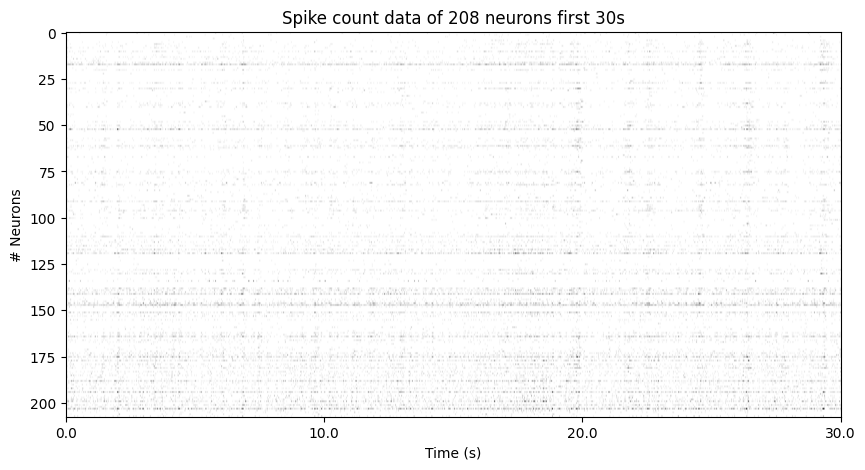

In [4]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,:30*FS], aspect = 'auto', vmax = np.round(100*neural_data[:,:30*FS].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,30*FS, 4))
ax1.set_xticklabels(np.linspace(0,30, 4))
ax1.set_title('Spike count data of 208 neurons first 30s')

In [5]:
# Split data and labels into train/validation

split_idx = int(0.8 * neural_data.shape[1])
# suggestion: 5%-20% depending on your dataset size; note that this splits the date
# into an early and late part, which might not be ideal for your data/experiment!
# As a more involved alternative, consider e.g. a nested time-series split.

train_data = neural_data.T[:split_idx]
valid_data = neural_data.T[split_idx:]

In [6]:
# identify indices for the first two trials in the section (note that the first 3 sec of the first trial is truncated)
Time0 = 18765 # in s
TimeEnd = 20279.99 # in s
Trial1 = [18762.33, 18768.42] # in s
Trial2 = [18782.34, 18784.58] # in s
Trial3 = [18784.64, 18787.27] # in s
Trial4 = [18787.32, 18791.06] # in s

Ind_first4trials = [0, int((Trial4[1]-Time0)*FS)] # in train_data.shape

Trial5end = [20259.66, 20261.5]
Trial4end = [20261.57, 20267.74]
Trial3end = [20274.07, 20275.78]
Trial2end = [20275.85, 20277.71]
Trial1end = [20277.81, 20283.19]
Ind_last5trials = [int((Trial5end[0]-TimeEnd)*FS-1) ,-1] # in valid_data.shape and in neural_data

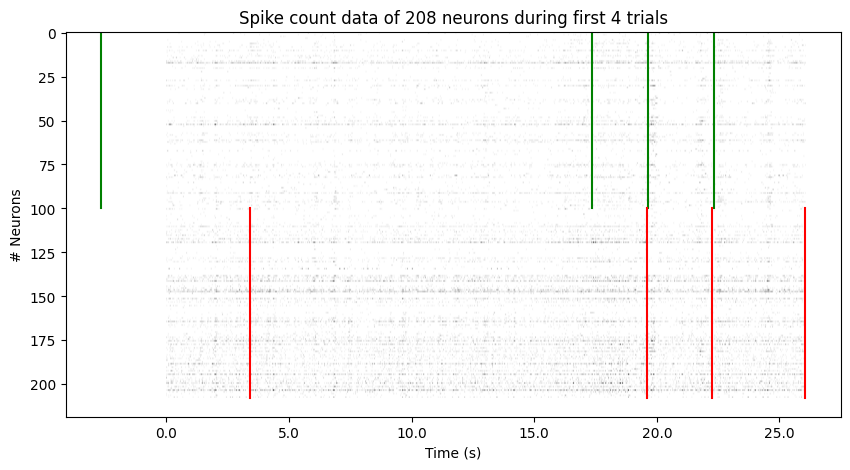

In [7]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,Ind_first4trials[0]:Ind_first4trials[1]], aspect = 'auto', vmax = np.round(100*neural_data[:,Ind_first4trials[0]:Ind_first4trials[1]].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,30*FS, 7))
ax1.set_xticklabels(np.linspace(0,30, 7))
ax1.set_title('Spike count data of 208 neurons during first 4 trials')
ax1.plot([(Trial2[0] - Time0)*FS, (Trial2[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial1[0] - Time0)*FS, (Trial1[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial3[0] - Time0)*FS, (Trial3[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial4[0] - Time0)*FS, (Trial4[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial2[1] - Time0)*FS, (Trial2[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial1[1] - Time0)*FS, (Trial1[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial3[1] - Time0)*FS, (Trial3[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial4[1] - Time0)*FS, (Trial4[1] - Time0)*FS], [100, 208], color='red')

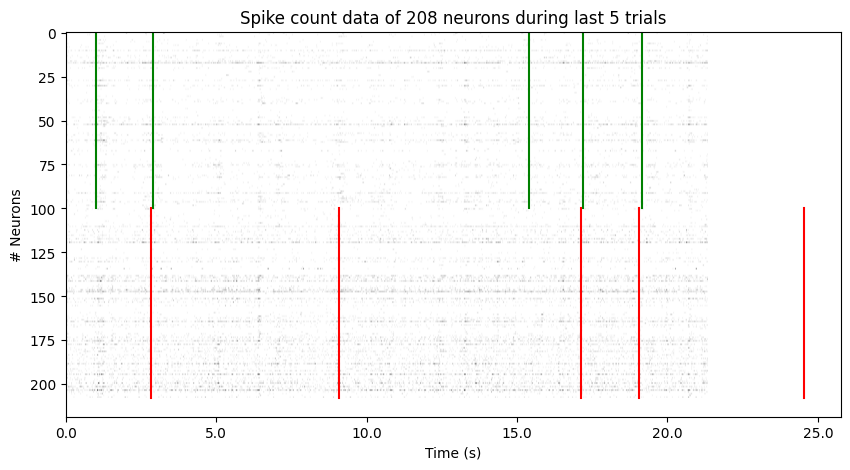

In [8]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,Ind_last5trials[0]-FS:Ind_last5trials[1]], aspect = 'auto', vmax = np.round(100*neural_data[:,Ind_last5trials[0]-FS:Ind_last5trials[1]].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,25*FS, 6))
ax1.set_xticklabels(np.linspace(0,25, 6))
ax1.set_title('Spike count data of 208 neurons during last 5 trials')
ax1.plot([FS, FS], [0, 100], color='green')
ax1.plot([(Trial4end[0]*FS - (Trial5end[0]*FS -FS)), (Trial4end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial3end[0]*FS - (Trial5end[0]*FS -FS)), (Trial3end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial2end[0]*FS - (Trial5end[0]*FS -FS)), (Trial2end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial1end[0]*FS - (Trial5end[0]*FS -FS)), (Trial1end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial5end[1]*FS - (Trial5end[0]*FS -FS)), (Trial5end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial4end[1]*FS - (Trial5end[0]*FS -FS)), (Trial4end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial3end[1]*FS - (Trial5end[0]*FS -FS)), (Trial3end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial2end[1]*FS - (Trial5end[0]*FS -FS)), (Trial2end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial1end[1]*FS - (Trial5end[0]*FS -FS)), (Trial1end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')


In [9]:
def plot_cebra(embtrain, embval, cebra_model, label):
    # plot the embedding for training set
    print('plotting the embedding for training data')
    fig1 = plt.figure(figsize=(15,5))
    ax1 = fig1.add_subplot(1,2,1, projection='3d') # Initialize 3D axes
    colors = np.tile(np.arange(100),int(embtrain.shape[0]/100)+1)
    colors = colors[:len(embtrain[:,0])]
    ax1.scatter(embtrain[:,0], embtrain[:,1], embtrain[:,2], cmap = 'magma', c = colors, s=1)
    ax1.set_title("Embedding train set " + label)

    # plot the embedding for validating set
    print('plotting the embedding for validating data')
    ax2 = fig1.add_subplot(1,2,2, projection='3d') # Initialize 3D axes
    colors = np.tile(np.arange(100),int(embval.shape[0]/100)+1)
    colors = colors[:len(embval[:,0])]
    ax2.scatter(embval[:,0], embval[:,1], embval[:,2], cmap = 'magma', c = colors, s=1)
    ax2.set_title("Embedding Valid set " + label)

    fig2 = plt.figure(figsize=(15,5))
    # plot the loss
    print('plotting the Loss')
    ax3 = fig2.add_subplot(1,2,1)
    cebra.plot_loss(cebra_model, ax=ax3)
    ax3.set_title("Loss " + label)

    # plot the goodness of fit history
    print('plotting the goodness of fit')
    ax4 = fig2.add_subplot(1,2,2)
    gof_valid_history = cebra.sklearn.metrics.goodness_of_fit_history(cebra_model)
    ax4.plot(gof_valid_history)
    ax4.set_title("GoF " + label)

In [10]:
import cebra.models
print(str(len(cebra.models.get_options())) + ' different models')
print(cebra.models.get_options())
print(str(len(cebra.models.get_options('resample*'))) + ' resample models')
print(cebra.models.get_options('resample*'))
print(str(len(cebra.models.get_options('offset*'))) + ' offset models')
print(cebra.models.get_options('offset*'))
print(str(len(cebra.models.get_options('supervised*'))) + ' supervised models')
print(cebra.models.get_options('supervised*'))


147 different models
['offset10-model', 'offset10-model-mse', 'offset5-model', 'offset1-model-mse', 'offset1-model', 'offset1-model-v2', 'offset1-model-v3', 'offset1-model-v4', 'offset1-model-v5', 'offset40-model-4x-subsample', 'resample-model', 'offset20-model-4x-subsample', 'resample5-model', 'offset4-model-2x-subsample', 'resample1-model', 'supervised10-model', 'supervised1-model', 'offset36-model', 'offset36-model-dropout', 'offset36-model-more-dropout', 'offset40-model', 'offset50-model', 'offset15-model', 'offset20-model', 'offset10-model-mse-tanh', 'offset1-model-mse-tanh', 'offset1-model-mse-clip-1000-1000', 'offset1-model-mse-clip-1000-100', 'offset1-model-mse-clip-1000-50', 'offset1-model-mse-clip-1000-25', 'offset1-model-mse-clip-1000-20', 'offset1-model-mse-clip-1000-15', 'offset1-model-mse-clip-1000-10', 'offset1-model-mse-clip-1000-5', 'offset1-model-mse-clip-1000-1', 'offset1-model-mse-clip-100-1000', 'offset1-model-mse-clip-100-100', 'offset1-model-mse-clip-100-50', 'of

When defining a model, the parameter time_offsets define the distance in time steps between each reference index and its positive sample for the time contrastive learning.
The Offset parameter defined by the model architecture (ex: offset10-model vs offset5-model) corresponds to the width of the data matrix that is extrated from the data for each sample (ref, pos or neg) and centered around the time of the sample. This matrix is then fed to the convolutional neural network to calculate and optimize sample distances (it is sort of the size of the receptive field).

In our usage case, with a data sample frequency of 100Hz, and sound events that can be as short as 70ms, we want to fix the offset of the model architecture to 5 time steps = 50ms (20ms before 30ms after) and so for time contrastive learning, where the positive sample of a given ref sample is just time-offset further (after) than the ref sample, we want to fix time_offset to 1 as it gives the best fit according to notebooks 4. The matrices of these samples will overlap by quite a lot.

Exploring the effect of changing the model architecture with fix dimension and time offset

In [11]:
# Define fix parameters
Output_dim = 15
Time_offset = 1

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset5-model',
      output_dimension=15)
Fitting the model
calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit


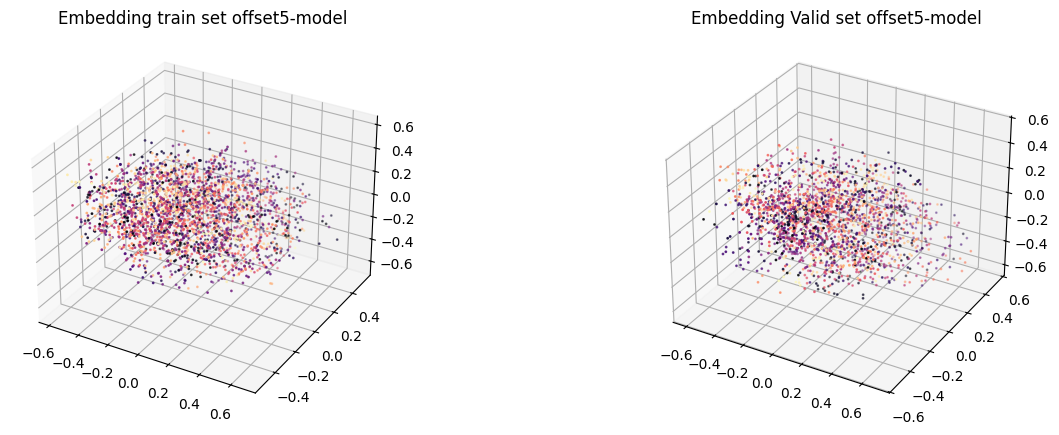

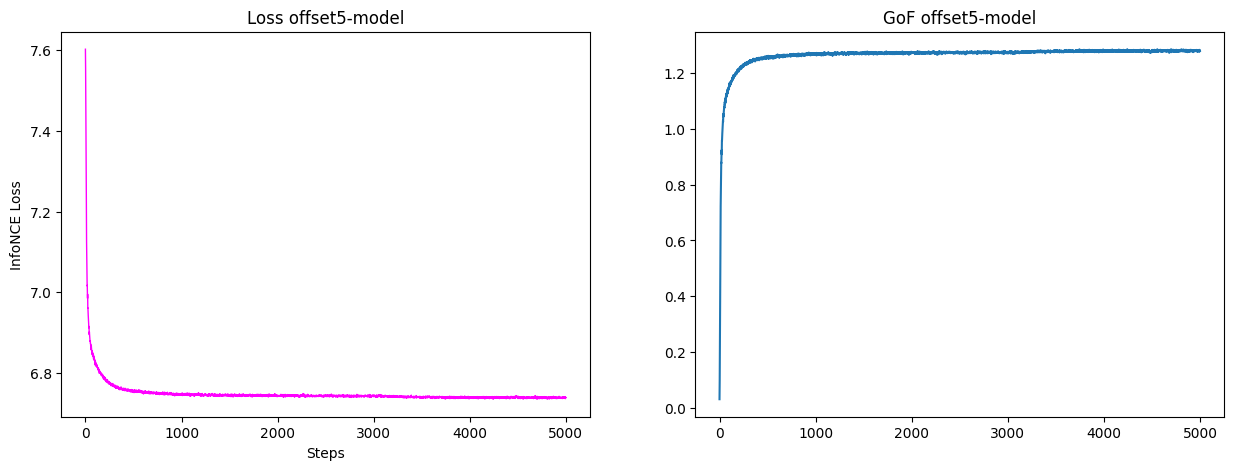

In [12]:
Model_arch = "offset5-model"
cebra_Offset5 = CEBRA(
    model_architecture = Model_arch,
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_Offset5)

# fit the model
print('Fitting the model')
cebra_Offset5.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_Offset5.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_Offset5.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_Offset5, Model_arch)


CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      output_dimension=15)
Fitting the model
calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit


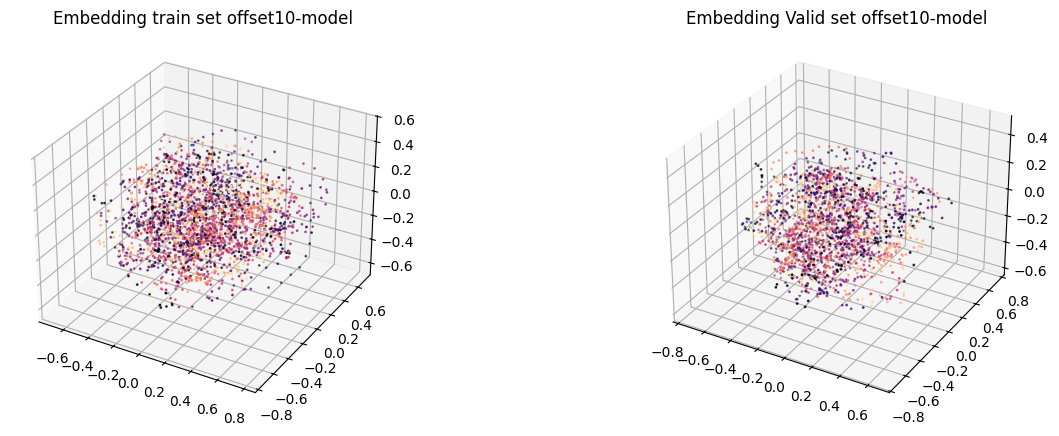

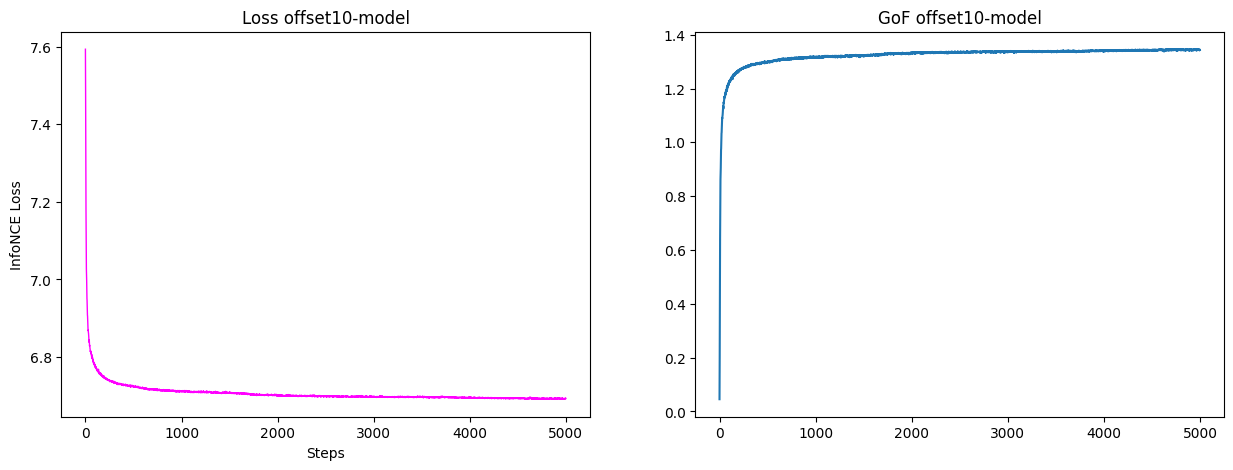

In [13]:
Model_arch = "offset10-model"
cebra_Offset10 = CEBRA(
    model_architecture = Model_arch,
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_Offset10)

# fit the model
print('Fitting the model')
cebra_Offset10.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_Offset10.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_Offset10.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_Offset10, Model_arch)


CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, output_dimension=15)
Fitting the model
calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit


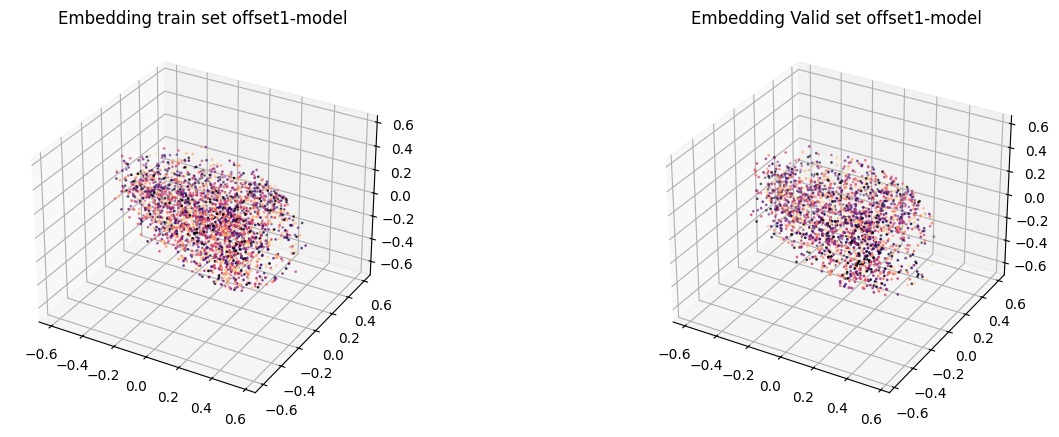

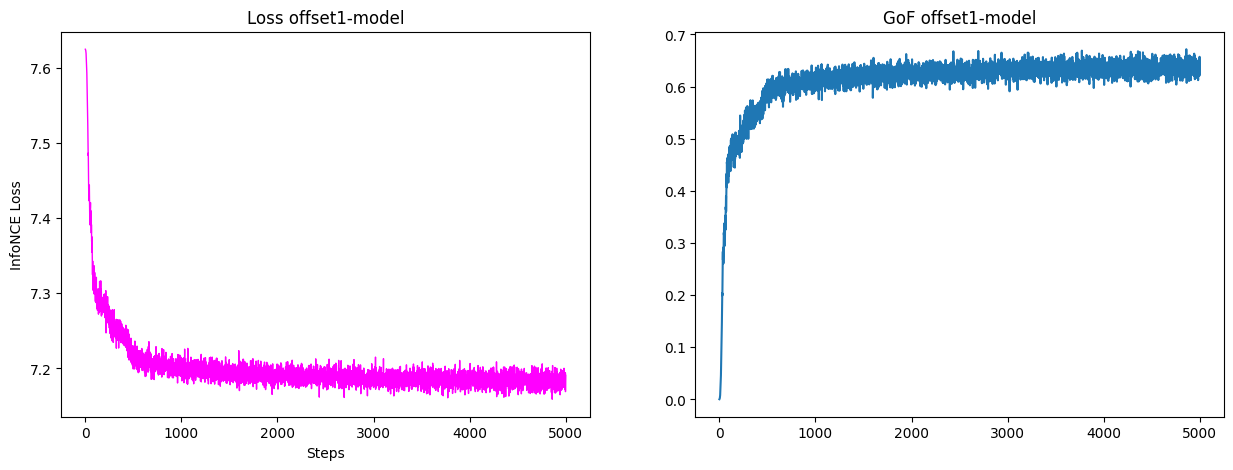

In [14]:
Model_arch = "offset1-model"
cebra_Offset1 = CEBRA(
    model_architecture = Model_arch,
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_Offset1)

# fit the model
print('Fitting the model')
cebra_Offset1.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_Offset1.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_Offset1.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_Offset1, Model_arch)


CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset36-model',
      output_dimension=15, verbose=True)
Fitting the model


pos: -0.9926 neg:  7.6608 total:  6.6681 temperature:  1.0000: 100%|██████████| 5000/5000 [04:47<00:00, 17.38it/s]


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit


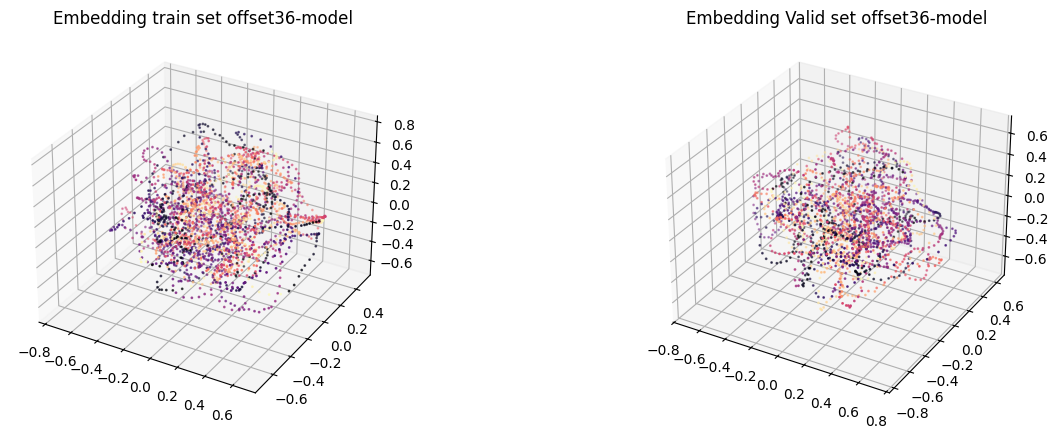

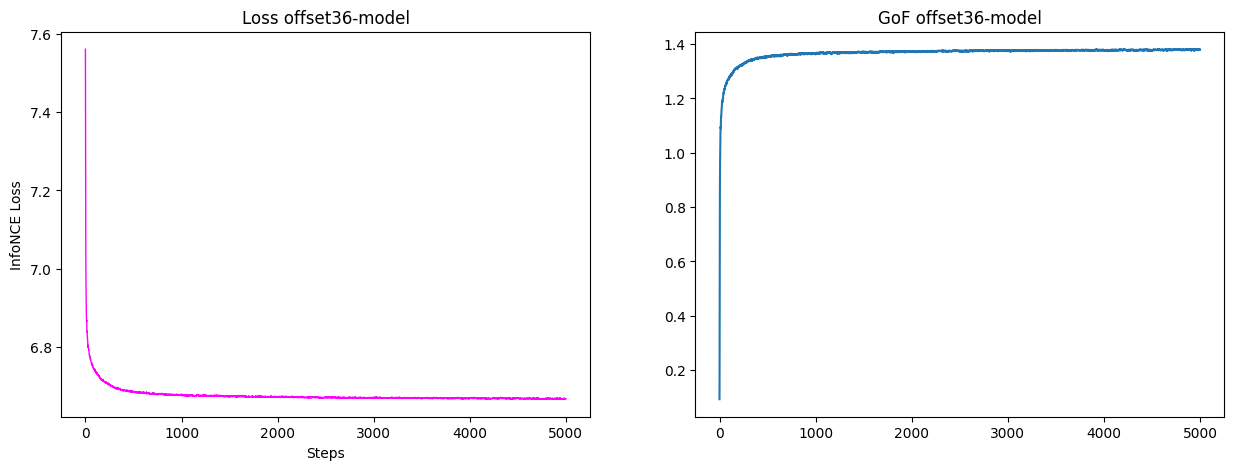

In [15]:
Model_arch = "offset36-model" 
cebra_Offset36= CEBRA(
    model_architecture = Model_arch,
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True
)

print(cebra_Offset36)

# fit the model
print('Fitting the model')
cebra_Offset36.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_Offset36.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_Offset36.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_Offset36, Model_arch)

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset40-model',
      output_dimension=15, verbose=True)
Fitting the model


pos: -0.9934 neg:  7.6608 total:  6.6674 temperature:  1.0000: 100%|██████████| 5000/5000 [05:29<00:00, 15.16it/s]


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit


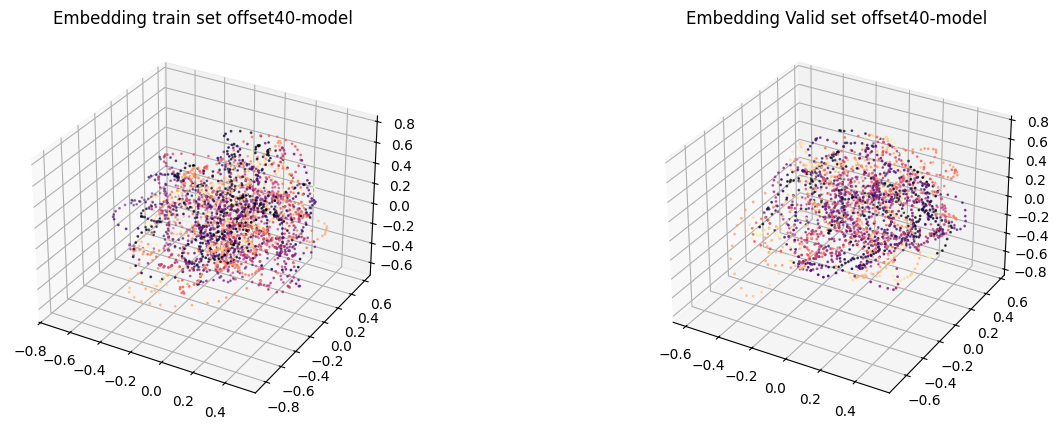

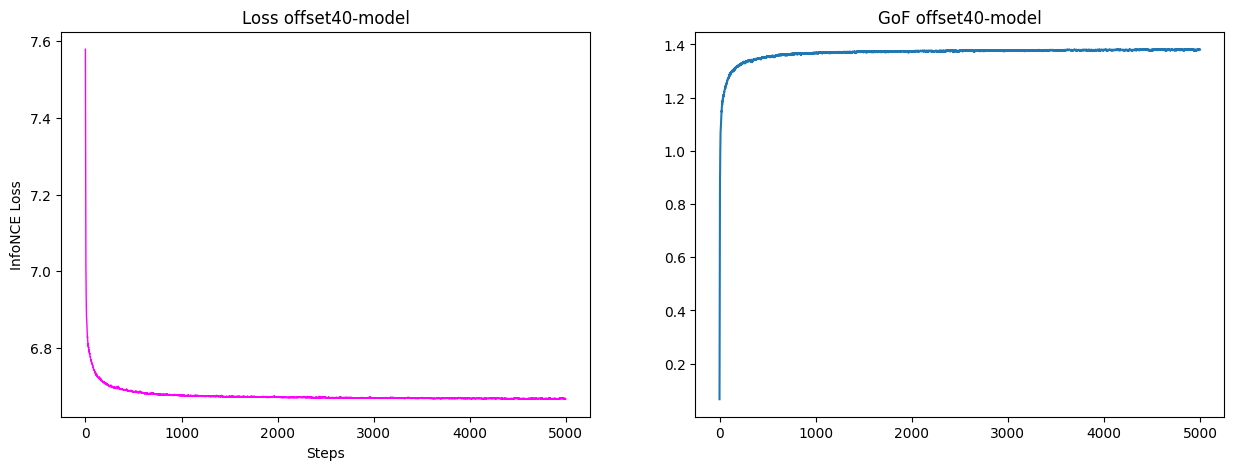

In [16]:
Model_arch = "offset40-model" 
cebra_Offset40= CEBRA(
    model_architecture = Model_arch,
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True
)

print(cebra_Offset40)

# fit the model
print('Fitting the model')
cebra_Offset40.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_Offset40.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_Offset40.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_Offset40, Model_arch)

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=15, verbose=True)
Fitting the model


pos: -0.9943 neg:  7.6615 total:  6.6672 temperature:  1.0000: 100%|██████████| 5000/5000 [07:39<00:00, 10.89it/s]


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit


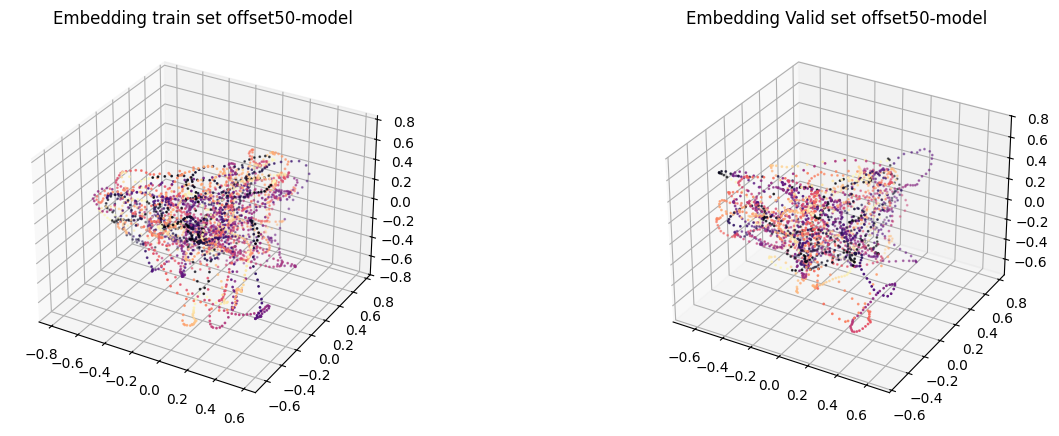

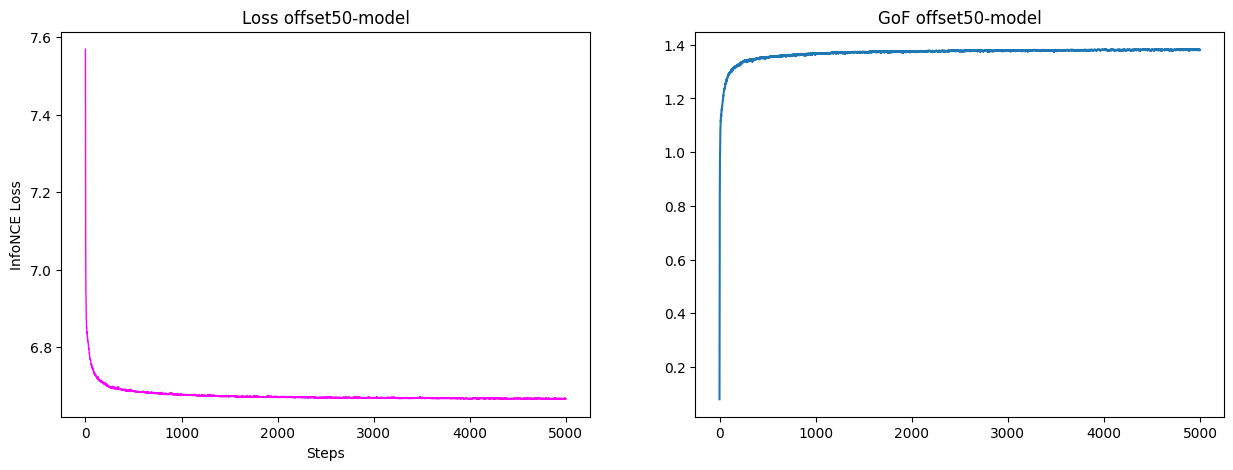

In [17]:
Model_arch = "offset50-model" 
cebra_Offset50= CEBRA(
    model_architecture = Model_arch,
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True
)

print(cebra_Offset50)

# fit the model
print('Fitting the model')
cebra_Offset50.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_Offset50.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_Offset50.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_Offset50, Model_arch)

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset15-model',
      output_dimension=15, verbose=True)
Fitting the model


pos: -0.9824 neg:  7.6618 total:  6.6794 temperature:  1.0000: 100%|██████████| 5000/5000 [01:43<00:00, 48.46it/s]


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit


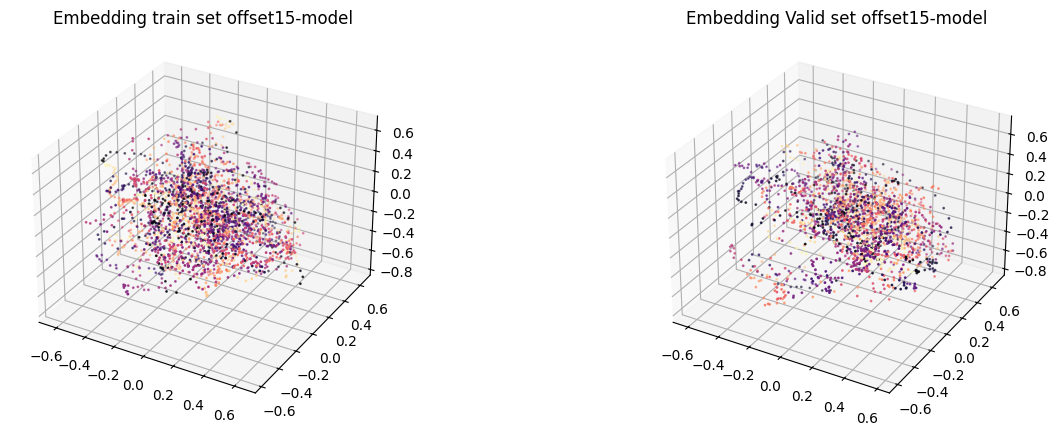

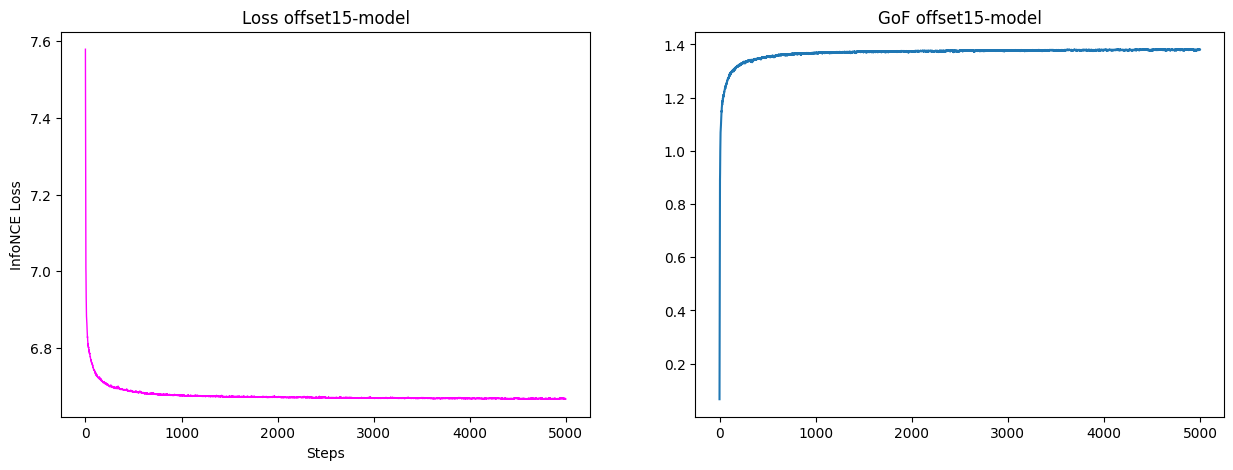

In [18]:
Model_arch = "offset15-model" 
cebra_Offset15= CEBRA(
    model_architecture = Model_arch,
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True
)

print(cebra_Offset15)

# fit the model
print('Fitting the model')
cebra_Offset15.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_Offset15.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_Offset15.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_Offset40, Model_arch)

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset20-model',
      output_dimension=15, verbose=True)
Fitting the model


pos: -0.9873 neg:  7.6612 total:  6.6739 temperature:  1.0000: 100%|██████████| 5000/5000 [02:15<00:00, 36.89it/s]


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit


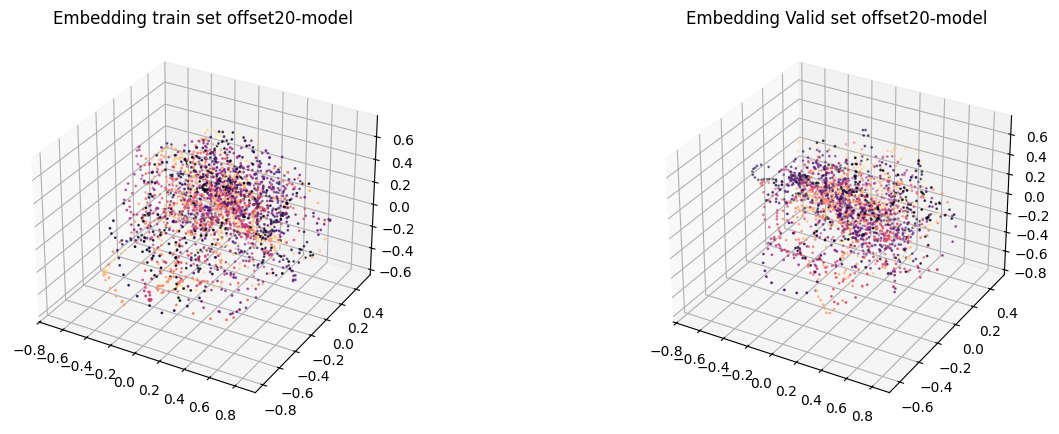

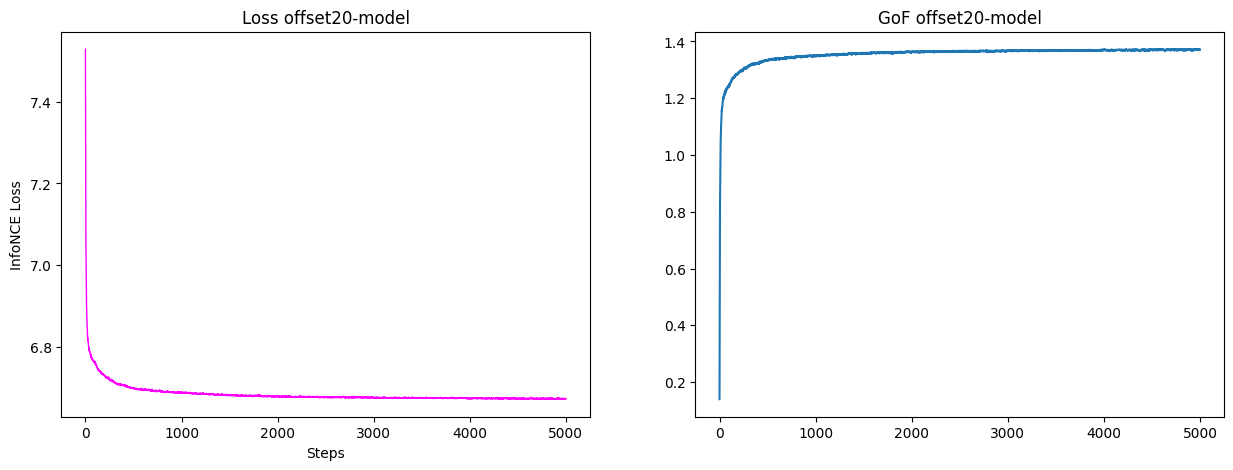

In [19]:
Model_arch = "offset20-model" 
cebra_Offset20= CEBRA(
    model_architecture = Model_arch,
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True
)

print(cebra_Offset20)

# fit the model
print('Fitting the model')
cebra_Offset20.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_Offset20.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_Offset20.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_Offset20, Model_arch)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

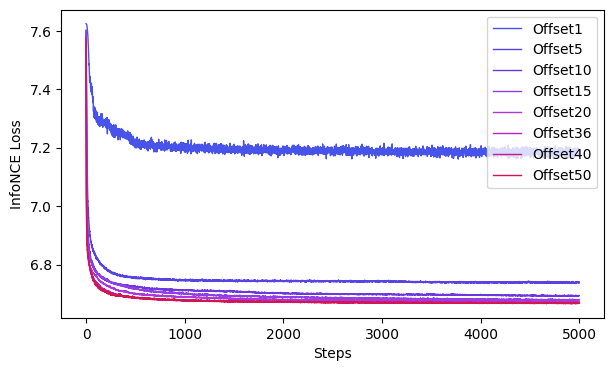

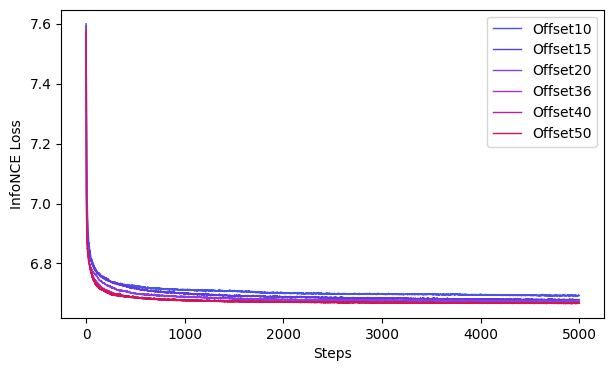

In [20]:
# compare Losses
# Labels to be used for the legend of the plot
labels = ["Offset1","Offset5", "Offset10", "Offset15", "Offset20", "Offset36", "Offset40", "Offset50"]

cebra.compare_models([cebra_Offset1, cebra_Offset5, cebra_Offset10, cebra_Offset15, cebra_Offset20, cebra_Offset36, cebra_Offset40, cebra_Offset50], labels)
# Labels to be used for the legend of the plot
labels = ["Offset10", "Offset15", "Offset20", "Offset36", "Offset40", "Offset50"]

cebra.compare_models([cebra_Offset10, cebra_Offset15, cebra_Offset20, cebra_Offset36, cebra_Offset40, cebra_Offset50], labels)

100%|██████████| 500/500 [00:16<00:00, 30.55it/s]


Text(0.5, 0, 'Filter size')

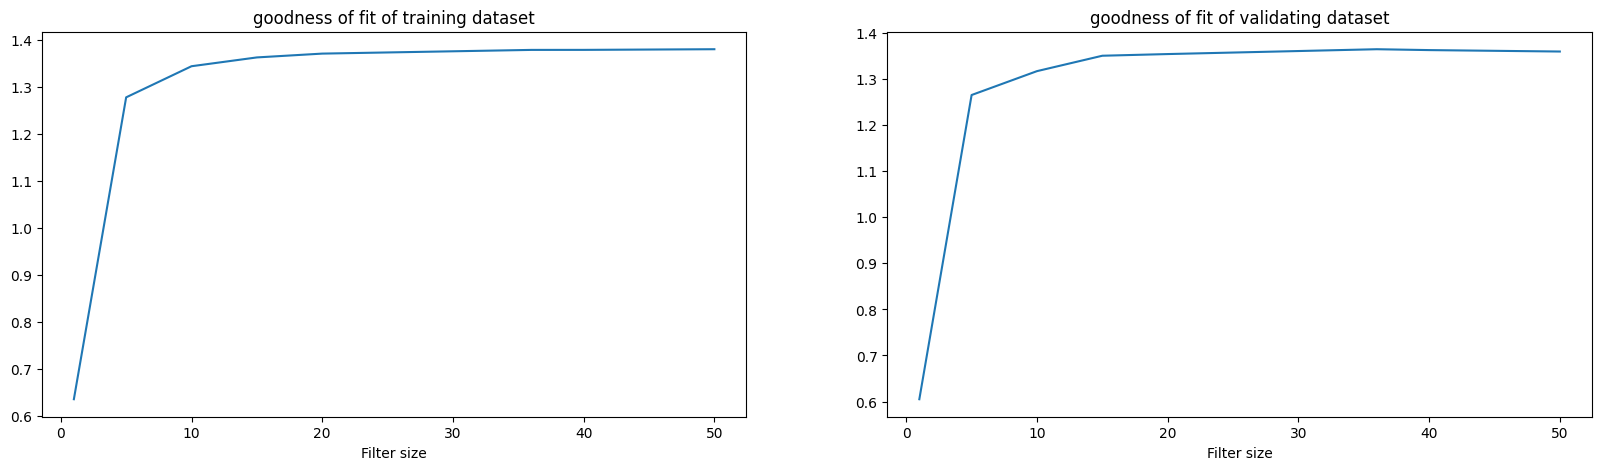

In [21]:
# Evaluate the model performance
goodness_of_fit_train = []
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset1,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset5,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset10,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset15,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset20,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset36,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset40,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset50,
                                                     train_data))
fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot([1,5,10,15,20,36,40,50], goodness_of_fit_train)
ax1.set_title('goodness of fit of training dataset')
ax1.set_xlabel('Filter size')

goodness_of_fit_valid = []
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset1,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset5,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset10,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset15,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset20,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset36,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset40,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset50,
                                                     valid_data))
ax2 = fig.add_subplot(1,2,2)
ax2.plot([1,5,10,15,20,36,40,50], goodness_of_fit_valid)
ax2.set_title('goodness of fit of validating dataset')
ax2.set_xlabel('Filter size')

Text(0.5, 0, 'Filter size')

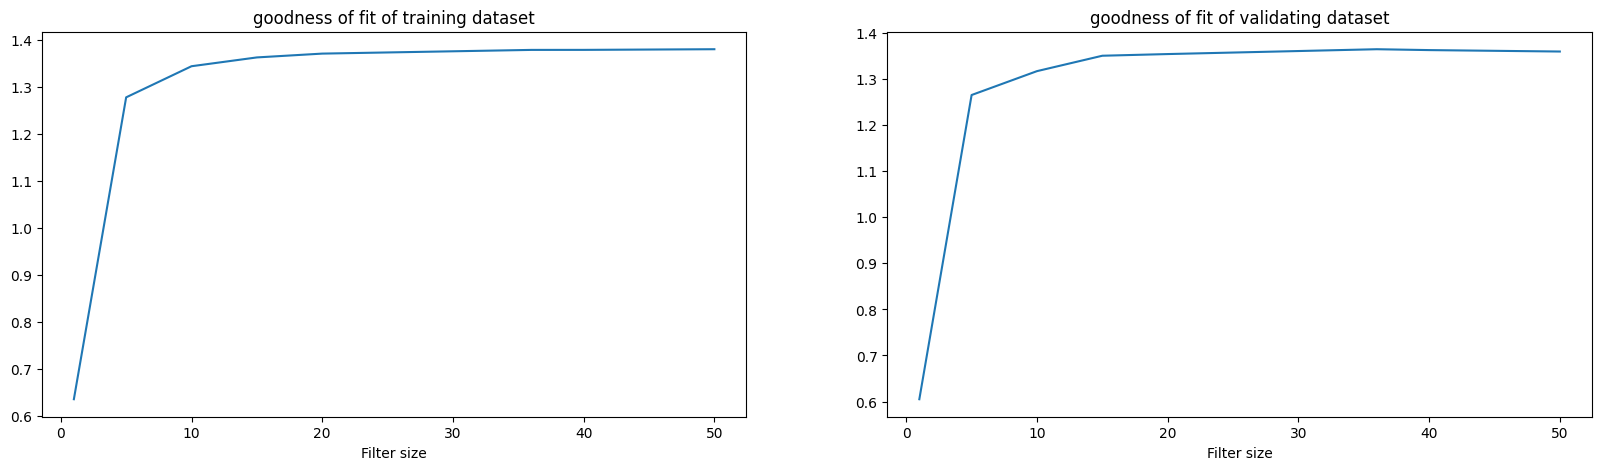

In [22]:
fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot([1,5,10,15,20,36,40,50], goodness_of_fit_train)
ax1.set_title('goodness of fit of training dataset')
ax1.set_xlabel('Filter size')
ax2 = fig.add_subplot(1,2,2)
ax2.plot([1,5,10,15,20,36,40,50], goodness_of_fit_valid)
ax2.set_title('goodness of fit of validating dataset')
ax2.set_xlabel('Filter size')

In [23]:
modelArch_Filter_size = [1,5,10,15,20,36,40,50]
neuro_path = '/Users/elie/Library/CloudStorage/Box-Box/ManipBerkeleyZF/neuro_PurWhi_WF/'
filename = '%s/GoodnessFit_countData_Modvar_TimeOffset1_Dim15.pkl' % (neuro_path)
with open(filename, 'wb') as f:
    pickle.dump({'goodness_of_fit_train': goodness_of_fit_train, 'goodness_of_fit_valid': goodness_of_fit_valid, 'Filter_size': modelArch_Filter_size}, f)

In [24]:
goodness_of_fit_valid

[0.6051126014984409,
 1.2652673216564512,
 1.3170851962996577,
 1.3505178999243934,
 1.3541496314213,
 1.3646529655058222,
 1.3627625996247368,
 1.3596546516099923]